<a href="https://colab.research.google.com/github/flatironinstitute/2026-flatiron-cmb-summer-school/blob/main/notebooks/CMB_School_Mapmaking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMB Mapmaking

### Acknowledgments and Dependencies
This notebook is based on the [2024 ACT-SPT Analysis School](https://github.com/jeffmcm1977/CMBAnalysis_SummerSchool) (see credits) and slightly adapted by Simone Aiola for the [2026 Flatiron CMB Summer School](https://www.simonsfoundation.org/event/cmb-summer-school-2026/).

This notebook uses concepts from the `Simulating the CMB` and `Simulating SZ and Point Sources` notebooks for the input sky map, and from `Modeling Instrumental Noise and Beams` for filtering (towards the end of the notebook). 

(credits: Jeff McMahon, Renee Hlozek, Sigurd Naess, with further revisions and contributions by Alex van Engelen, Alexandra Rahlin, Mathew Madhavacheril, Joshua Kim, Zach Atkins, Will Coulton, Melanie Archipley, Tom Crawford.

### CMB Observations in a Nutshell
CMB telescopes observe by scanning across the sky and recording the response of each detector as a function of time, as well as pointing information. 
The detector response time series is commonly referred to as time-ordered data (TOD).  Each CMB field is usually observed many times over the course of one or more seasons, yielding a large number of overlapping TODs.   
CMB observations are usually performed with constant-elevation scans: the telescope points to a chosen azimuth and elevation, then moves back and forth in azimuth with a given scan throw (az-min, az-max) and scan speed. As the telescope scans, the sky drifts above the telescope due to Earth's rotation, thus scanning a selected patch of sky, although the elevation is kept constant. 
From Chile, a selected patch of sky can be observed both as it rises above the horizon and as it sets. When those observations are combined, they create a cross-linked region that leaves a distinct signature on the resulting CMB maps.

### What we will see  
In this notebook, you will (1) model TODs for a map that is observed horizontally and vertically to create a cross-linked set of TODs, (2) add 1/f noise to create TODs similar to what would be output from a CMB instrument, and (3) you will use several mapmaking codes to reconstruct maps from these time streams. 
The mapmaking codes include (i) a simple binned average that works well if the TODs have negligible white noise or by pre-whitening the data with a filter, and (ii) an iterative maximum-likelihood (ML) mapmaker that accounts for the noise correlations from the atmosphere.
Exercises will guide you through the differences between cross-linked and non-cross-linked maps, and the impacts of filtering before and after mapmaking.
NOTE: We will limit this exercise to only the CMB temperature.

## First we read in the necessary libraries from previous code modules.

In [1]:
# !python -c "import cmb_modules" || ( \
#     wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/cmb_modules.py \
#     wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/constants.py \
#     wget https://raw.githubusercontent.com/flatironinstitute/2026-flatiron-cmb-summer-school/refs/heads/main/notebooks/CAMB_fiducial_cosmo_scalCls.dat \
# )

In [2]:
import numpy as np
import matplotlib
import matplotlib.cm as cm
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import astropy.io.fits as fits

import constants as cs # the constants module
import cmb_modules # the module of functions

N = int(cs.N)
c_min = cs.c_min
c_max = cs.c_max
X_width =cs.X_width
Y_width = cs.Y_width
beam_size_fwhp = cs.beam_size_fwhp

pix_size = cs.pix_size
print("pixel size: ", pix_size)
print(X_width, Y_width)

Number_of_Sources  = cs.Number_of_Sources
Amplitude_of_Sources = cs.Amplitude_of_Sources
Number_of_Sources_EX = cs.Number_of_Sources_EX
Amplitude_of_Sources_EX = cs.Amplitude_of_Sources_EX

Number_of_SZ_Clusters  = cs.Number_of_SZ_Clusters
Mean_Amplitude_of_SZ_Clusters = cs.Mean_Amplitude_of_SZ_Clusters
SZ_beta = cs.SZ_beta
SZ_Theta_core = cs.SZ_Theta_core

pixel size:  0.5
8.533333333333333 8.533333333333333


## Recalculating the results from the previous stages
This creates a temperature map with CMB, point sources, and SZ sources; It also convolves the map with the beam. Noise will be added at the TOD level.

Number of sources required:  5000


/Users/licongxu/Study/2026-flatiron-cmb-summer-school/notebooks/cmb_modules.py:15: RuntimeWarning: invalid value encountered in divide
  ClTT = DlTT * 2 * np.pi / (ell * (ell + 1.0))


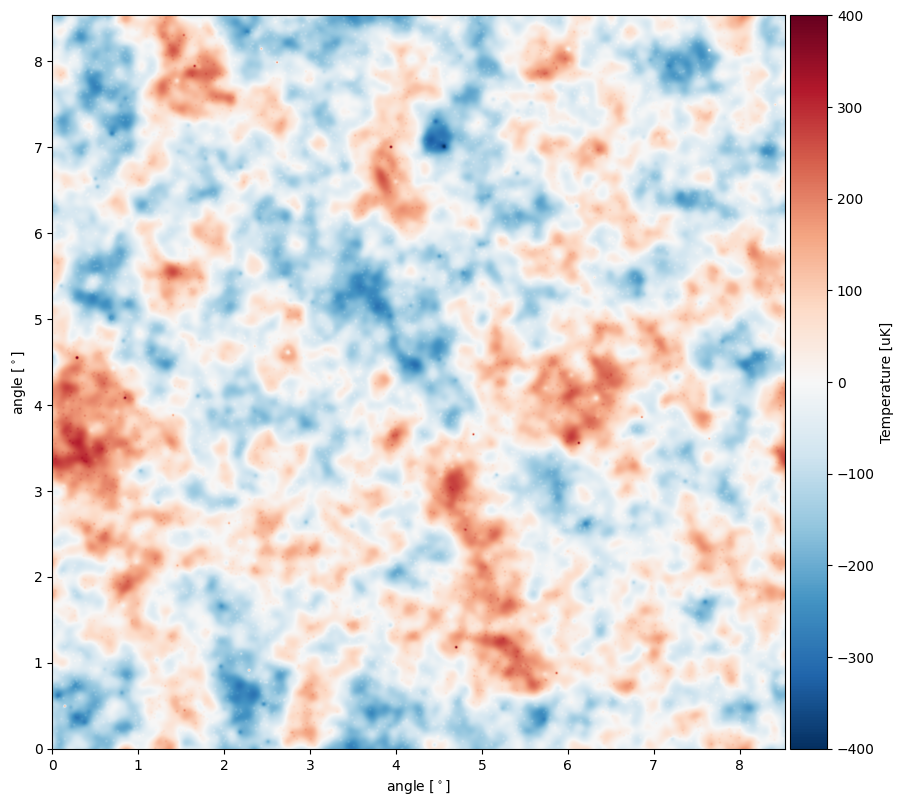

In [3]:
## Make a CMB map
ell, DlTT = np.loadtxt("CAMB_fiducial_cosmo_scalCls.dat", usecols=(0, 1), unpack=True)
CMB_T = cmb_modules.make_CMB_T_map(N,pix_size,ell,DlTT)

## make a point source map
PSMap = cmb_modules.Poisson_source_component(N,pix_size,Number_of_Sources,Amplitude_of_Sources)
PSMap += cmb_modules.Exponential_source_component(N,pix_size,Number_of_Sources_EX,Amplitude_of_Sources_EX)

## make an SZ map
SZMap,SZCat = cmb_modules.SZ_source_component(N,pix_size,Number_of_SZ_Clusters,\
                                  Mean_Amplitude_of_SZ_Clusters,SZ_beta,SZ_Theta_core,False)

## add them all together to get the sky map at a single frequency
total_map = CMB_T + PSMap + SZMap

## convolve with the beam
CMB_T_convolved = cmb_modules.convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,total_map)

## plot the result
p=cmb_modules.Plot_CMB_Map(CMB_T_convolved,c_min,c_max,X_width,Y_width)

## save the result as "sky", a variable that represents the simulated sky we will map below
sky = total_map

## Generating time streams from a simulated sky map
This is the first new piece of the notebook.  In this section, we simulate the telescope scanning across the map. For simplicity, we consider two scan directions: left-right and up-down. This code generates a list of pixel coordinates (x- and y-coordinates) in the order they are observed. This is what we usually refer to as `Pointing Information or Pointing Matrix (P)`.

(1024, 1024)
(2, 1048576)
1048576


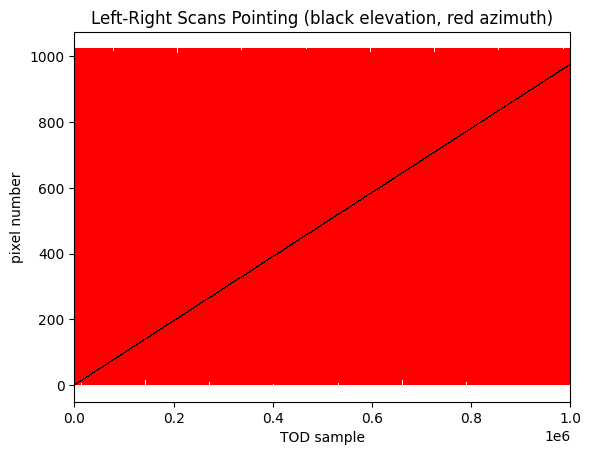

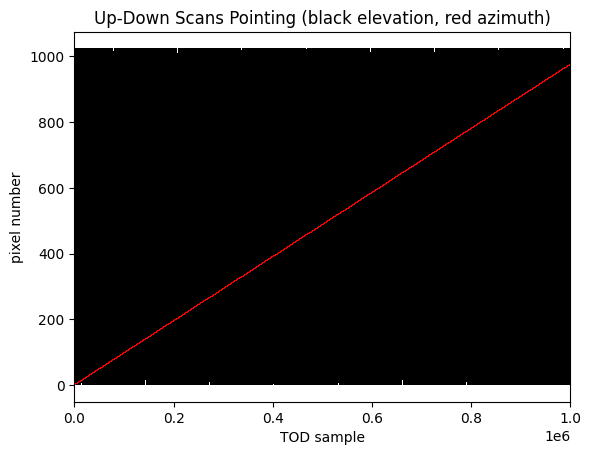

In [4]:
## A function to return the sequence of pixel indices as they are "observed" in these simulations
def sim_pointing(map, dir=0):
    """Simulate a telescope scanning across the given map. The scanning pattern is
    as simple as possible: The samples hit the center of each pixel, and we
    scan rowwise (dir=0) or columnwise (dir=1)."""
    # The pointing is an [{y,x},nsamp] array of pixel positions
    # The einsum stuff is just to swap the second and third axis
    # of pixmap, which contains the pixel coordinates of each pixel.
    pixmap = np.mgrid[:map.shape[-2],:map.shape[-1]]  ## makes two arrays of the x and y indices in the map
    pixmap[1,1::2, :] = pixmap[1,1::2, ::-1]          ## reverse ever other row so the scans go back and forth
    if dir == 0: point = pixmap.reshape(2,-1)         ## arranges these for L-R scans
    else:        point = np.roll(pixmap,1,axis=0).reshape(2,-1)   ## arranges these for U-D scans
    return point

## generate left-right scans
point_lr = sim_pointing(sky, 0)
print(sky.shape)
print(point_lr.shape)
print(1024 ** 2)

## generate Up-Down scans
point_ud = sim_pointing(sky, 1)

##Some plotting
plt.plot(point_lr[1,:],"r,")
plt.plot(point_lr[0,:],"k,")
plt.title("Left-Right Scans Pointing (black elevation, red azimuth)")
plt.ylabel("pixel number")
plt.xlabel("TOD sample")
plt.xlim(0,1e6)
plt.show()

plt.plot(point_ud[0,:],"k,")
plt.plot(point_ud[1,:],"r,")
plt.title("Up-Down Scans Pointing (black elevation, red azimuth)")
plt.ylabel("pixel number")
plt.xlabel("TOD sample")
plt.xlim(0,1e6)
plt.show()

<font color='red'>EXERCISE: </font>  Make a zoomed-in plot of the scan strategies above by adjusting the x limit for the plot to be much smaller. Describe the scan strategy based on what you see in these plots.

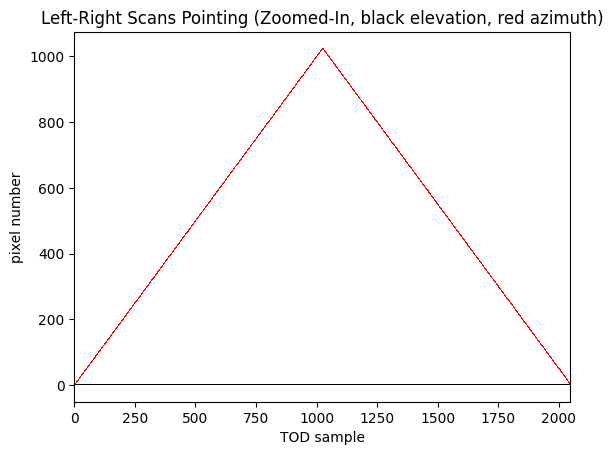

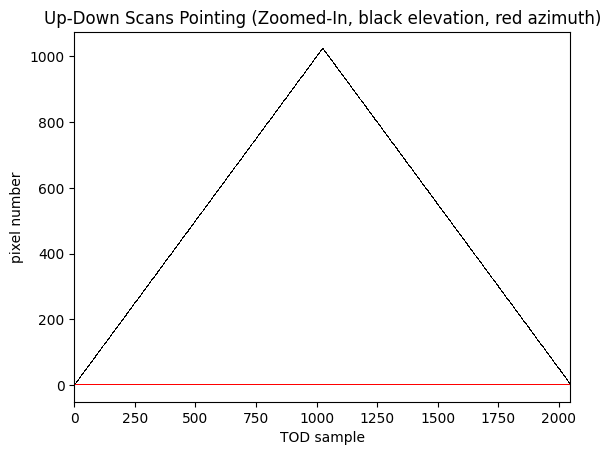

In [5]:
# Zoomed-in plotting for scan strategies
zoom_range = 2048  # Number of samples to show for zoom-in

plt.plot(point_lr[1,:zoom_range],"r,")
plt.plot(point_lr[0,:zoom_range],"k,")
plt.title("Left-Right Scans Pointing (Zoomed-In, black elevation, red azimuth)")
plt.ylabel("pixel number")
plt.xlabel("TOD sample")
plt.xlim(0, zoom_range)
plt.show()

plt.plot(point_ud[0,:zoom_range],"k,")
plt.plot(point_ud[1,:zoom_range],"r,")
plt.title("Up-Down Scans Pointing (Zoomed-In, black elevation, red azimuth)")
plt.ylabel("pixel number")
plt.xlabel("TOD sample")
plt.xlim(0, zoom_range)
plt.show()

#### Your discussion goes here

In [6]:
sky.shape
np.mean(sky)
np.std(sky)

95.19973056891286

### Noisless TODs
This code takes the pointing information generated above and makes a mock TOD with no noise.

(1048576,)
(1048576,)


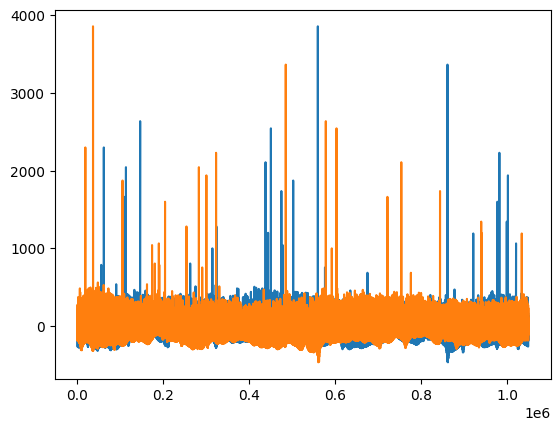

In [7]:
def Observe_map(map, point):
    """Pointing matrix: Project map to tod"""
    point = np.round(point).astype(int)
    return map[point[0],point[1]]  ## return the value of the map at each pointing, this forms the simulated time stream

noisless_tod_lr = Observe_map(sky, point_lr)
noisless_tod_ud = Observe_map(sky, point_ud)
print(noisless_tod_lr.shape)
print(noisless_tod_ud.shape)

plt.plot(noisless_tod_lr)
plt.plot(noisless_tod_ud)
plt.show()

<font color='red'>EXERCISE: </font>Explain the spikes in the TOD and discuss weather the RMS of the TOD makes sense.

#### Your discussion goes here

### Adding noise to the TOD
Here, we build a noise power spectrum for the atmospheric and instrumental noise. By default, we assume the instrumental noise has an amplitude of 40 $\mu$K per sample (1/2 arcmin pixels). The atmospheric signal is modeled as a simple power law with a 0.1s 1/f knee and a scan that spends $1/240$s in each pixel, which is equivalent to a $1^\circ/$s scan speed.   

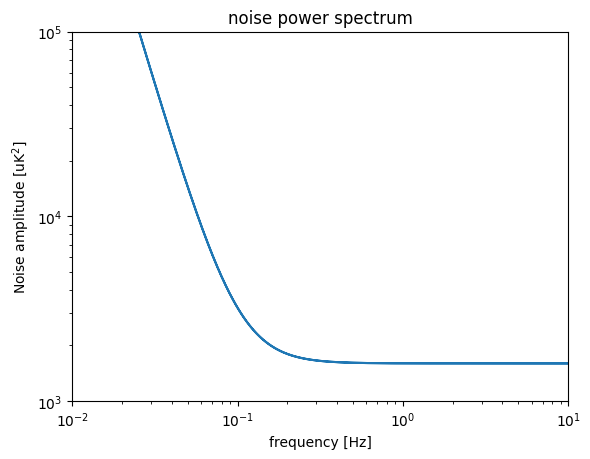

In [8]:
def sim_noise_spec(nsamp, dt=.00416, fknee=0.1, alpha=3, sigma=40):
    """Build a simple atmosphere + white noise model, and return it
    as a power spectrum."""
    freq   = np.abs(np.fft.fftfreq(nsamp, dt))
    return (1+(np.maximum(freq,freq[1])/fknee)**-alpha)*sigma**2

noise_spec_lr = sim_noise_spec(point_lr.shape[-1], dt=.00416, fknee=0.1, alpha=3, sigma=40)
noise_spec_ud = sim_noise_spec(point_ud.shape[-1], dt=.00416, fknee=0.1, alpha=3, sigma=40)
freq   = np.abs(np.fft.fftfreq(point_lr.shape[-1], .00416))

plt.loglog(freq,noise_spec_lr)
plt.title("noise power spectrum")
plt.xlabel("frequency [Hz]")
plt.ylabel("Noise amplitude [uK$^{2}$]")
plt.ylim(1e3,1e5)
plt.xlim(1e-2,10)
plt.show()

The next step is to generate a realziation of this noise and add it to the noisless time series.

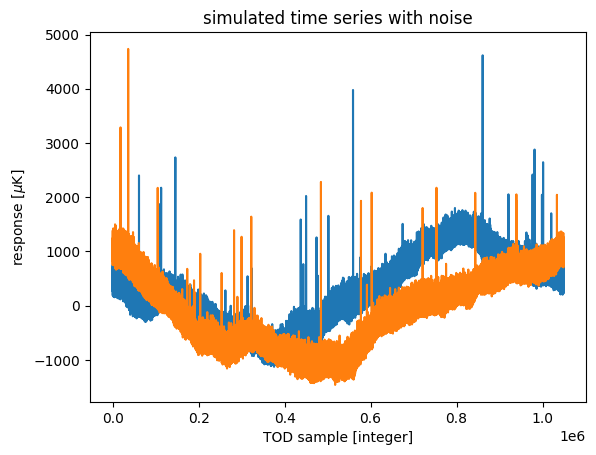

In [9]:
def sim_tod(map, point, noise_spec):
    """Simulate a noisy TOD using the model d = Pm + n"""
    tod    = Observe_map(map, point)
    rand   = np.fft.fft(np.random.standard_normal(tod.shape[-1]))
    fnoise = rand * noise_spec**0.5
    tod   += np.fft.ifft(fnoise).real
    return tod

tod_lr = sim_tod(sky, point_lr, noise_spec_lr)
tod_ud = sim_tod(sky, point_ud, noise_spec_ud)

plt.plot(tod_lr)
plt.plot(tod_ud)
plt.title("simulated time series with noise")
plt.ylabel(r"response [$\mu$K]")
plt.xlabel("TOD sample [integer]")
plt.show()

<font color='red'>EXERCISE: </font>  Typical detectors have noises of $\sim 300 \mu$K-$\sqrt{s}$.  Make a plot of what a time stream looks like with this instantaneous sensitivity so you can get a feel for what real data looks like.

In [10]:
## make your plots here

### Putting all the pieces together
For convenience, the following code bundles the TOD (signal and noise), with pointing information, and the noise spectrum into a class.   This object will be passed as input to the mapmaking codes we develop below.

Generating noisy TOD simulations


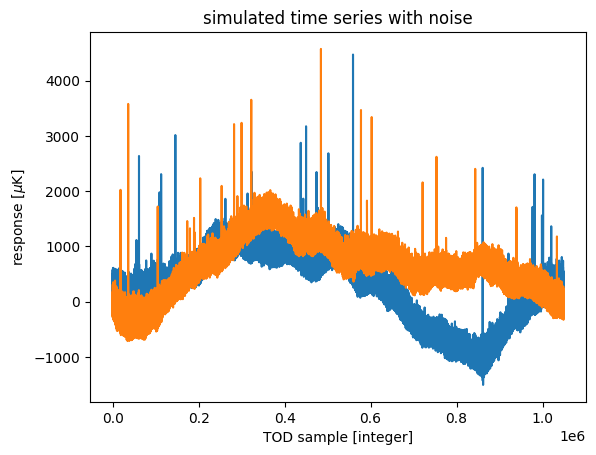

In [11]:
def sim_dataset(map, num_data=2, dt=.00416, fknee=0.1, alpha=3, sigma=40):
    """Simulate a dataset consisting of num_data scans across the sky.
    Returns a list of Data objects, each of which contains the tod,
    the pointing and the noise spectrum."""
    res = []
    for i in range(num_data):
        point = sim_pointing(map, i % 2)
        noise_spec = sim_noise_spec(point.shape[-1], dt=dt, fknee=fknee, alpha=alpha, sigma=sigma)
        tod = sim_tod(map, point, noise_spec)
        res.append(Data(tod, point, noise_spec))
    return res

class Data:
    def __init__(self, tod, point, noise_spec):
        self.tod   = tod
        self.point = point
        self.noise_spec = noise_spec
        
print("Generating noisy TOD simulations")
dataset  = sim_dataset(sky,num_data=2, dt=.00416, fknee=0.1, alpha=3, sigma=40)
for data in dataset:
    plt.plot(data.tod)

plt.title("simulated time series with noise")
plt.ylabel(r"response [$\mu$K]")
plt.xlabel("TOD sample [integer]")
plt.show()

# Naive mapmaking

Making maps from TODs is an inverse problem. It can be expressed in matrices as:
$$ P m = d.$$
Here $d$ is the TOD (which is a vector), $m$ is the sky map (which is also a vector), and $P$ is a (typically) rectangular matrix that specifies which pixel in the map was observed during each TOD sample. (NOTE: many TOD samples usually correspond to the same pixel in our sky map.   

To solve for a map $m$ given our TODs ($d$), we must invert the equation above. The standard technique is to use chi-squared minimization.  Expressed in matrices, this approach can be accomplished as derived here:
$$ P m = d$$
$$ P^tP m  = P^t d$$
$$ m = [P^tP]^{-1} P^t d.$$

In other words, we can use the pointing matrix to construct a matrix $[P^tP]^{-1} P^t$ that acts on the TODs to return an estimate for the map. The difficulty lies in implementing this when the number of samples in the TODs is large and noise is present.

We have entirely ignored noise at this point (i.e. our data $d$ is only modeled as the sky signal $m$).
So in this simplified case, what we do computationally is: 
- $P^t d$ = project our TOD $d$ onto a map, and accumulate the signal in each pixel from all the TODs
- $[P^tP]^{-1}$ = divide the accumulated signal, but the number of times the pixels has been observed.

Solving for map while ignoring noise correlations


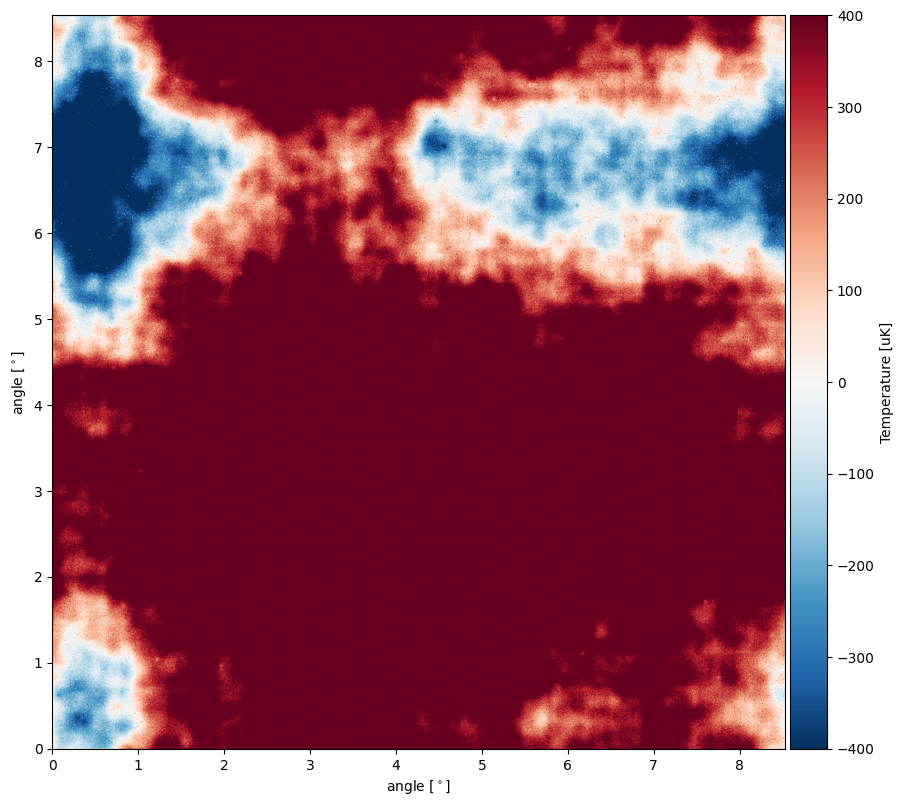

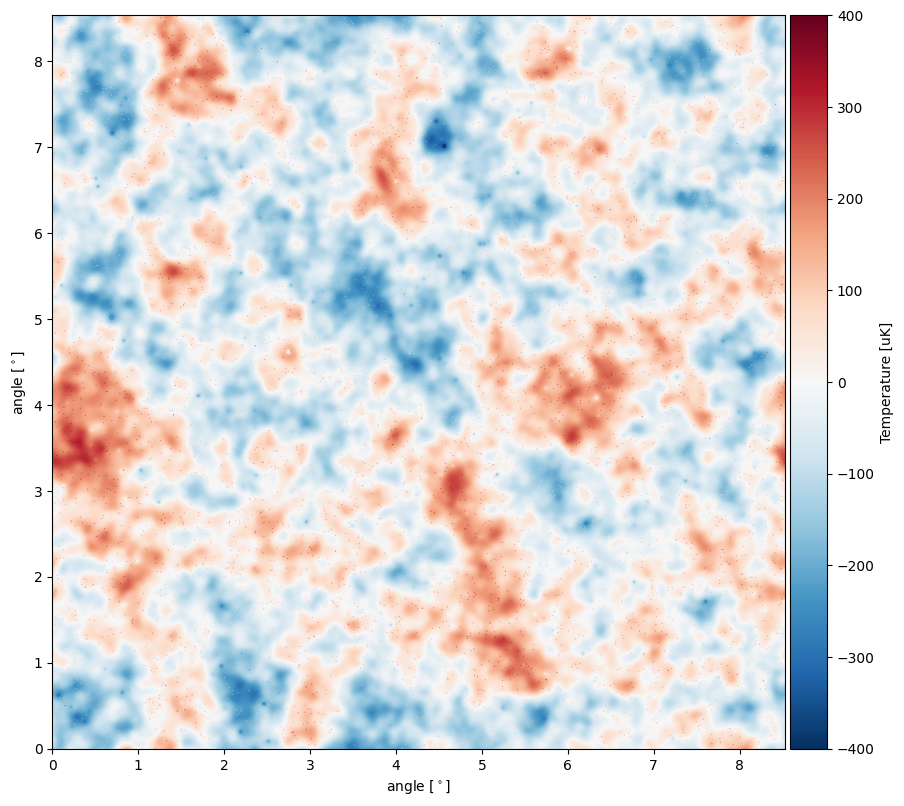

In [20]:
def solve_binned_average(dataset, shape):
    """Solve the simplified mapmaking equation Ax=b,
    where A = P'P and b = P'd, e.g. ignoring noise
    properties such as correlations."""
    rhs  = np.zeros(shape)
    hits = np.zeros(shape)
    for data in dataset:
        rhs  += PT(data.tod,    data.point, shape)
        hits += PT(data.tod*0+1, data.point, shape)
    return rhs/hits

def PT(tod, point, shape):
    """Transpose pointing matrix."""
    point = np.round(point).astype(int)
    point_flat = np.ravel_multi_index(point, shape[-2:])
    map = np.bincount(point_flat, tod, minlength=shape[-2]*shape[-1])
    map = map.reshape(shape[-2:])
    return map

print("Solving for map while ignoring noise correlations")
map_binned = solve_binned_average(dataset, sky.shape)
p=cmb_modules.Plot_CMB_Map(map_binned,c_min,c_max,X_width,Y_width)
p_sky = cmb_modules.Plot_CMB_Map(sky,c_min,c_max,X_width,Y_width)
##p=cmb_modules.Plot_CMB_Map(map_binned-sky,c_min,c_max,X_width,Y_width)  #for comparison

<font color='red'>EXERCISE: </font>  Do you see structures in common between this map and the input sky map?

#### Your discussion goes here

<font color='red'>EXERCISE: </font> Remake the TOD and this map by setting the 1/f knee to be very small. Compare the new result to the original input map?

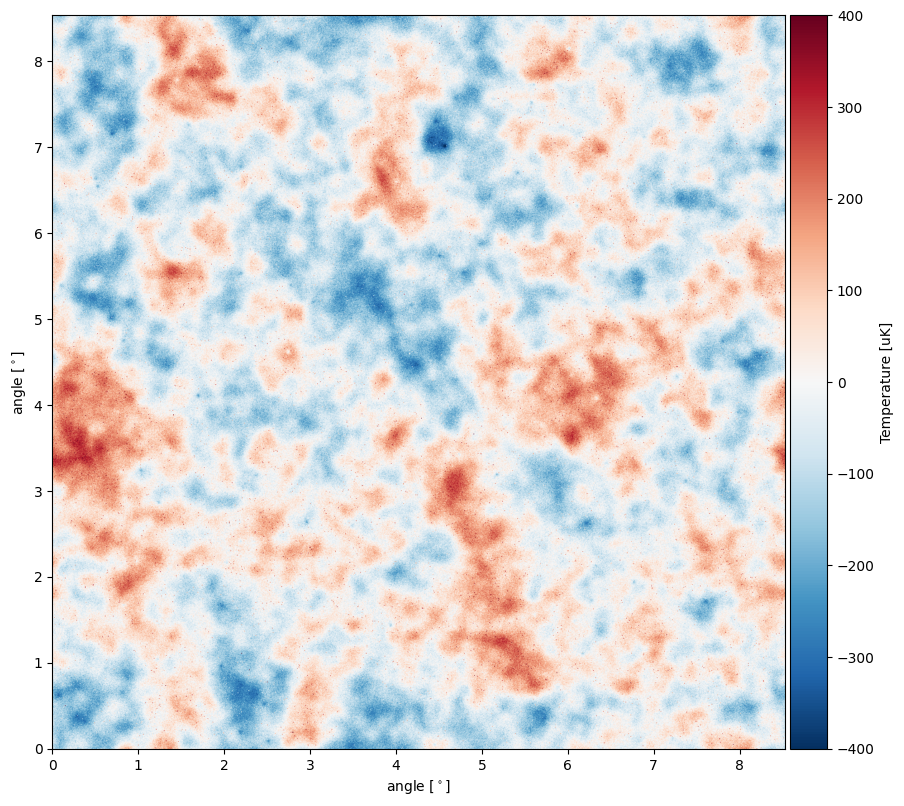

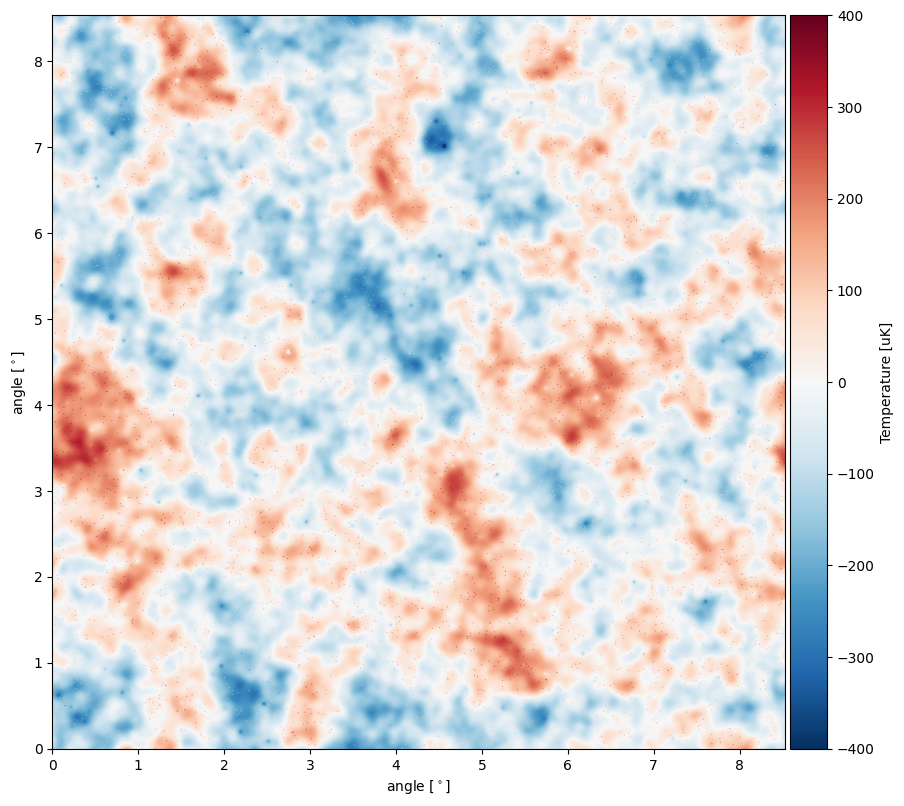

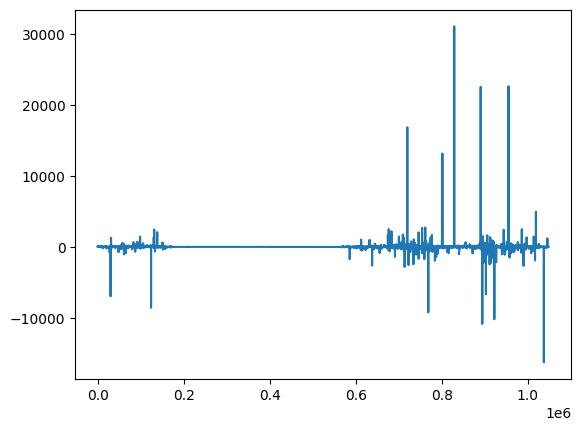

In [33]:
## code goes here
f_knee_small = 1e-6
dataset_smallknee  = sim_dataset(sky,num_data=2, dt=.00416, fknee=f_knee_small, alpha=3, sigma=40)
map_binned_smallknee = solve_binned_average(dataset_smallknee, sky.shape)
p=cmb_modules.Plot_CMB_Map(map_binned_smallknee,c_min,c_max,X_width,Y_width)
p_sky = cmb_modules.Plot_CMB_Map(sky,c_min,c_max,X_width,Y_width)
plt.plot(np.concatenate(map_binned_smallknee/map_binned))

#### Your discussion goes here

<font color='red'>EXERCISE: </font> First, reset the 1/f knee to its original value. Now filter the TOD using a high-pass filter with a knee frequency set to whiten the TODs. Remake the map and compare the new result to the input map. What is different?

In [14]:
## code goes here

#### Your discussion goes here

# Maximum-likelihood Mapmaking (including noise correlations)
Based on what we have seen above, we need to develop a mapmaking approach that accounts for the noise correlations in our data.

To do this, we implement a maximum-likelihood mapmaking approach. Expressed in matrix form, this is much like what we did above, except we include weighting by a new matrix $N$, whose elements encode the weight of each sample and correlations between samples in the TOD. With this matrix, our mapmaking approach can be derived as follows:
$$ P m = d$$
$$ N^{-1} P m = N^{-1} d$$
$$ P^tN^{-1}P m  = P^tN^{-1} d      $$
$$ m = [P^tN^{-1}P]^{-1} P^tN^{-1} d.  $$

In summary, the matrix $[P^tN^{-1}P]^{-1} P^tN^{-1}$ can be applied to the TOD $d$ to produce the map $m$.

Given that the matrix $N$ must have off-diagonal terms to encode noise correlations such as from $1/f$ noise, building this matrix is highly non-trivial. Computationally, the operation $N^{-1} d$ is executed in Fourier space.   

In most cases, solving for $m$ is not possible. So we use Conjugate-gradient techniques to solve $P^tN^{-1}P m  = P^tN^{-1} d$. [(see Wikipedia article)](https://en.wikipedia.org/wiki/Conjugate_gradient_method). These techniques are iterative, and thus we must run many iterations to arrive at an acceptable estimate for our map.

### Let's start with Cross-linked TODs

Solving for map while taking noise correlations into account
iteration:    1 conjugate gradient error:   1.4363554e-02
iteration:    2 conjugate gradient error:   1.1456025e-03
iteration:    3 conjugate gradient error:   6.2457113e-05
iteration:    4 conjugate gradient error:   1.3525204e-05
iteration:    5 conjugate gradient error:   9.6488653e-08
iteration:    6 conjugate gradient error:   7.7863815e-09
iteration:    7 conjugate gradient error:   1.5681580e-10
iteration:    8 conjugate gradient error:   4.0949602e-12
iteration:    9 conjugate gradient error:   1.5308900e-13
iteration:   10 conjugate gradient error:   1.1774926e-14
iteration:   11 conjugate gradient error:   5.3307664e-15
iteration:   12 conjugate gradient error:   1.2037008e-13
iteration:   13 conjugate gradient error:   5.0113081e-12
iteration:   14 conjugate gradient error:   1.2987373e-10
iteration:   15 conjugate gradient error:   5.1639075e-09
iteration:   16 conjugate gradient error:   3.8036757e-08
iteration: 

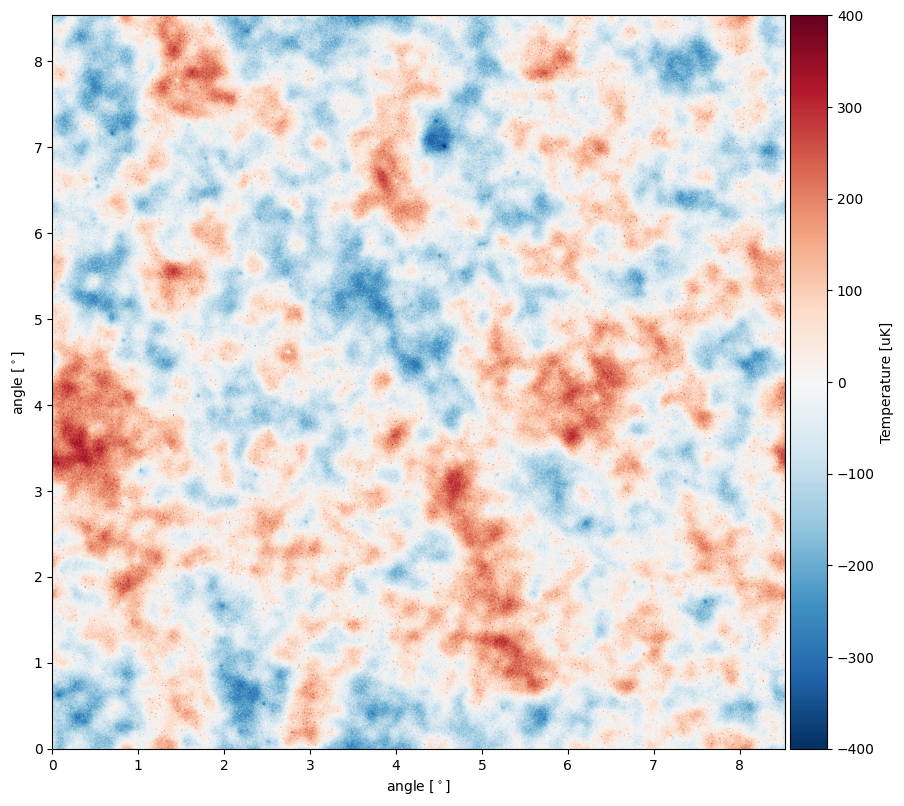

In [15]:
def solve_full(dataset, shape, niter=100, verbose=True):
    """Solve the full map-making equation
    Ax=b, where A = P'N"P and b = P'N"d."""
    # Set up our A matrix. We don't compute
    # explicitly because it's too big. Instead,
    # we define it as a function that can be applied
    # to a vector x. We will then use Conjugate Gradients
    # to invert it.
    def A(x):
        # x is 1d because the conjugate gradient solver works
        # on 1d arrays. So start by expanding it to 2d.
        x   = x.reshape(shape)
        res = x*0
        for data in dataset:
            tod  = Observe_map(x, data.point)
            tod  = mul_inv_noise(tod, data.noise_spec)
            res += PT(tod, data.point, shape)
        return res.reshape(-1)
    # Build our right-hand side b
    b = np.zeros(shape)
    for data in dataset:
        tod = mul_inv_noise(data.tod, data.noise_spec)
        b  += PT(tod, data.point, shape)
    # And solve
    cg = CG(A, b.reshape(-1))
    while cg.i < niter:
        cg.step()
        if verbose: print("iteration: %4d conjugate gradient error: %15.7e" % (cg.i, cg.err))
    return cg.x.reshape(shape)

def mul_inv_noise(tod, noise_spec):
    """Multiply by the inverse noise matrix. We assume that the noise
    is stationary, which means that it can be represented by a simple
    power spectrum noise_spec. This function is used to apply inverse
    variance weighting to the data."""
    ftod  = np.fft.fft(tod)
    ftod /= noise_spec
    return np.fft.ifft(ftod).real

def default_M(x):     return np.copy(x)
def default_dot(a,b): return a.dot(np.conj(b))
class CG:
    """A simple Preconditioned Conjugate gradients solver. Solves
    the equation system Ax=b."""
    def __init__(self, A, b, x0=None, M=default_M, dot=default_dot):
        """Initialize a solver for the system Ax=b, with a starting guess of x0 (0
        if not provided). Vectors b and x0 must provide addition and multiplication,
        as well as the .copy() method, such as provided by numpy arrays. The
        preconditioner is given by M. A and M must be functors acting on vectors
        and returning vectors. The dot product may be manually specified using the
        dot argument. This is useful for MPI-parallelization, for example."""
        # Init parameters
        self.A   = A
        self.b   = b
        self.M   = M
        self.dot = dot
        if x0 is None:
            self.x = b*0
            self.r = b
        else:
            self.x   = x0.copy()
            self.r   = b-self.A(self.x)
        # Internal work variables
        n = b.size
        self.z   = self.M(self.r)
        self.rz  = self.dot(self.r, self.z)
        self.rz0 = float(self.rz)
        self.p   = self.z
        self.err = np.inf
        self.d   = 4
        self.arz = []
        self.i   = 0
    def step(self):
        """Take a single step in the iteration. Results in .x, .i
        and .err being updated. To solve the system, call step() in
        a loop until you are satisfied with the accuracy. The result
        can then be read off from .x."""
        Ap = self.A(self.p)
        alpha = self.rz/self.dot(self.p, Ap)
        self.x += alpha*self.p
        self.r -= alpha*Ap
        self.z = self.M(self.r)
        next_rz = self.dot(self.r, self.z)
        self.err = next_rz/self.rz0
        beta = next_rz/self.rz
        self.rz = next_rz
        self.p = self.z + beta*self.p
        self.arz.append(self.rz*alpha)
        self.i += 1

print("Solving for map while taking noise correlations into account")
map_full  = solve_full(dataset, sky.shape,niter=50)

p=cmb_modules.Plot_CMB_Map(map_full - np.mean(map_full),c_min,c_max,X_width,Y_width)

### Now, let's check without cross-linking

Solving for map while taking noise correlations into account
iteration:    1 conjugate gradient error:   2.8434727e-03
iteration:    2 conjugate gradient error:   6.1292989e-05
iteration:    3 conjugate gradient error:   3.2247395e-06
iteration:    4 conjugate gradient error:   2.6727241e-06
iteration:    5 conjugate gradient error:   1.6354242e-06
iteration:    6 conjugate gradient error:   1.0419257e-06
iteration:    7 conjugate gradient error:   6.9462645e-07
iteration:    8 conjugate gradient error:   6.7931316e-07
iteration:    9 conjugate gradient error:   5.6385244e-07
iteration:   10 conjugate gradient error:   4.5053687e-07
iteration:   11 conjugate gradient error:   4.0930951e-07
iteration:   12 conjugate gradient error:   3.1561501e-07
iteration:   13 conjugate gradient error:   2.8061343e-07
iteration:   14 conjugate gradient error:   2.2976798e-07
iteration:   15 conjugate gradient error:   2.1450141e-07
iteration:   16 conjugate gradient error:   2.1242406e-07
iteration: 

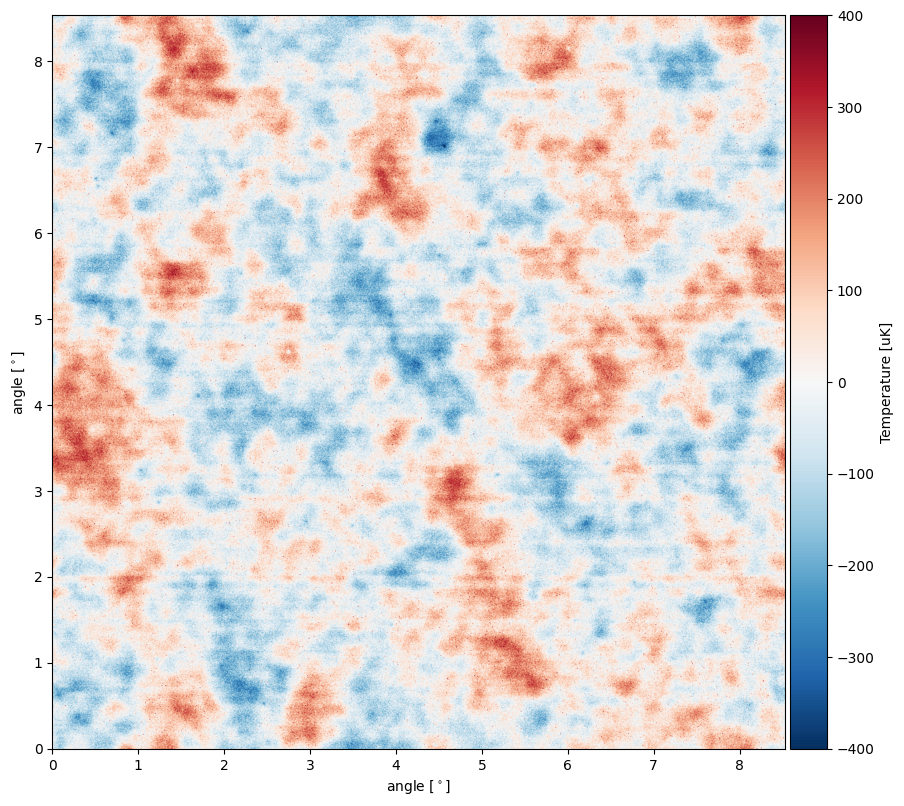

In [16]:
print("Solving for map while taking noise correlations into account")
map_single = solve_full(dataset[0:1], sky.shape,niter=50)

p=cmb_modules.Plot_CMB_Map(map_single - np.mean(map_single),c_min,c_max,X_width,Y_width)

<font color='red'>EXERCISE: </font>  Compare the cross-linked and non-crosslinked maps. The horizontal strips in the non-crosslinked maps are referred to (uncreatively) as stripes.

#### Your discussion goes here

<font color='red'>EXERCISE: </font>  Make plots of these maps in 2-d fourier space

(1024, 1024)
(1024, 1024)


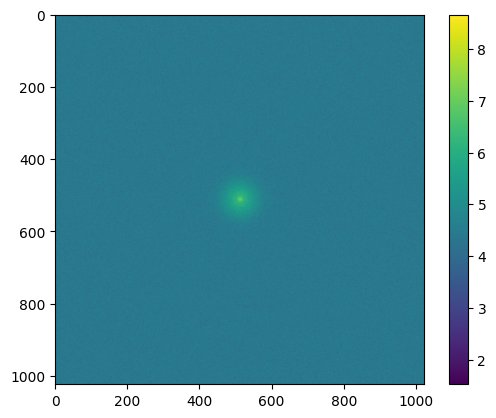

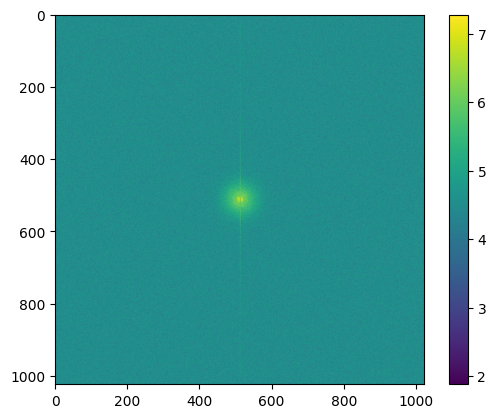

In [36]:
print(map_full.shape)
print(map_single.shape)
map_full_fourier = np.fft.fft2(map_full)
map_full_fourier = np.fft.fftshift(map_full_fourier)
plt.imshow(np.log10(np.abs(map_full_fourier)))
plt.colorbar()
plt.show()
map_single_fourier = np.fft.fft2(map_single)
map_single_fourier = np.fft.fftshift(map_single_fourier)
plt.imshow(np.log10(np.abs(map_single_fourier)))
plt.colorbar()
plt.show()



 Compare these 2d fourier plots here. Be sure to note where modes are missing or de-weighted in each map.

#### Your discussion goes here

<font color='red'>EXERCISE: </font>  Filter the non-crosslinked map to remove the stripes. This can be accomplished by masking the relevant modes in your 2d fourier plot before inverse Fourier transforming to create the map.

In [ ]:
## your code goes here


comment on the difference between the filter map non-crosslinked map, the crosslinked map, and the input map.   Make difference plots if that seems useful.

#### Your discussion goes here